In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df= pd.read_csv("ai_resume_screening.csv")

In [4]:
df.head()

,years_experience,skills_match_score,education_level,project_count,resume_length,github_activity,shortlisted
0,6,84.7,Bachelors,7,234,158,No
1,3,59.1,Masters,5,502,77,No
2,12,100.0,Masters,12,753,381,Yes
3,14,66.8,High School,8,529,407,Yes
4,10,99.6,Bachelors,10,754,331,Yes


In [5]:
df.tail()

,years_experience,skills_match_score,education_level,project_count,resume_length,github_activity,shortlisted
29995,9,77.4,Bachelors,13,691,434,Yes
29996,5,77.8,Bachelors,9,473,149,No
29997,1,64.6,Bachelors,7,247,82,No
29998,7,94.8,Bachelors,12,584,409,Yes
29999,14,77.3,Masters,25,694,790,Yes


In [6]:
df.shape

(30000, 7)

In [7]:
df.columns

Index(['years_experience', 'skills_match_score', 'education_level',
       'project_count', 'resume_length', 'github_activity', 'shortlisted'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   years_experience    30000 non-null  int64  
 1   skills_match_score  30000 non-null  float64
 2   education_level     30000 non-null  str    
 3   project_count       30000 non-null  int64  
 4   resume_length       30000 non-null  int64  
 5   github_activity     30000 non-null  int64  
 6   shortlisted         30000 non-null  str    
dtypes: float64(1), int64(4), str(2)
memory usage: 1.9 MB


In [9]:
df.describe()

,years_experience,skills_match_score,project_count,resume_length,github_activity
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,7.506567,73.682653,10.646267,572.584700,325.260667
std,4.624104,16.765909,4.634047,178.709918,159.951803
min,0.000000,0.500000,0.000000,150.000000,0.000000
25%,3.750000,62.100000,7.000000,441.000000,202.000000
50%,7.000000,74.300000,10.000000,574.000000,321.000000
75%,12.000000,86.500000,14.000000,709.000000,443.000000
max,15.000000,100.000000,25.000000,900.000000,842.000000


In [10]:
df.dtypes

years_experience        int64
skills_match_score    float64
education_level           str
project_count           int64
resume_length           int64
github_activity         int64
shortlisted               str
dtype: object

In [11]:
df['shortlisted'].value_counts()

shortlisted
Yes    20966
No      9034
Name: count, dtype: int64

In [12]:
df['shortlisted'].value_counts(normalize=True)*100

shortlisted
Yes    69.886667
No     30.113333
Name: proportion, dtype: float64

<Axes: xlabel='shortlisted', ylabel='count'>

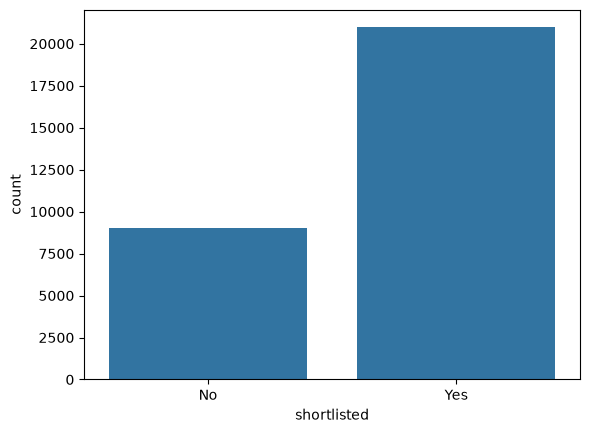

In [13]:
sns.countplot(x='shortlisted',data=df)

Text(0.5, 1.0, 'shortlisted Distribution')

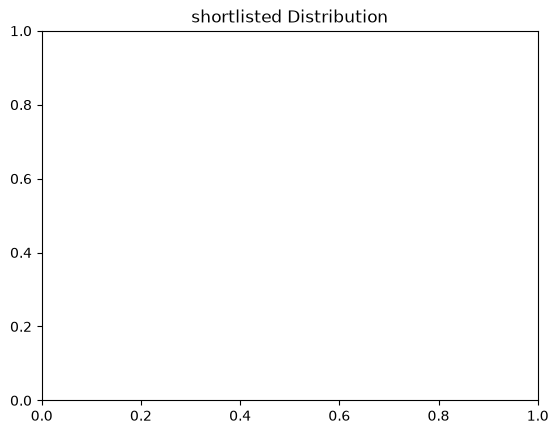

In [14]:
plt.title('shortlisted Distribution')

In [15]:
plt.show()

In [16]:
df.isnull().sum()

years_experience      0
skills_match_score    0
education_level       0
project_count         0
resume_length         0
github_activity       0
shortlisted           0
dtype: int64

In [17]:
(df.isnull().sum()/len(df))*100

years_experience      0.0
skills_match_score    0.0
education_level       0.0
project_count         0.0
resume_length         0.0
github_activity       0.0
shortlisted           0.0
dtype: float64

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df=df.drop_duplicates()

In [20]:
df.shape

(30000, 7)

In [21]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
numerical_cols

Index(['years_experience', 'skills_match_score', 'project_count',
       'resume_length', 'github_activity'],
      dtype='str')

In [22]:
categorical_cols=df.select_dtypes(include=['int64','float64']).columns
categorical_cols

Index(['years_experience', 'skills_match_score', 'project_count',
       'resume_length', 'github_activity'],
      dtype='str')

In [23]:
for col in categorical_cols:
    print(col)
    print(df[col].unique())
    print("-"*50)

years_experience
[ 6  3 12 14 10  7  4  9  2  5  1 11 13 15  0  8]
--------------------------------------------------
skills_match_score
[ 84.7  59.1 100.   66.8  99.6  74.1  87.5  54.2  80.4  87.   52.1  37.5
  68.3  60.8  82.   62.3  56.8  93.5  65.9  70.5  60.   54.6  60.6  80.2
  70.1  78.7  52.2  69.3  86.3  61.5  72.9  92.8  88.5  76.2  63.7  77.6
  79.5  62.6  72.   69.5  75.8  74.4  77.7  69.7  82.9  66.1  52.5  86.9
  83.1  85.6  51.5  61.   45.9  72.7  73.   95.5  69.4  64.3  81.   66.2
  74.8  86.1  60.9  79.7  59.9  45.6  71.5  63.8  70.7  72.4  94.2  72.3
  53.4  52.6  80.7  60.1  53.2  94.   48.2  57.8  77.4  78.4  54.7  51.6
  69.6  82.6  63.3  97.4  90.3  53.8  53.3  96.4  97.2  73.9  44.4  83.2
  79.   81.6  85.3  84.5  68.2  94.5  85.1  95.4  99.4  89.6  70.9  67.4
  20.6  72.6  85.5  89.8  83.7  62.4  75.3  75.9  55.2  98.5  70.   80.1
  98.7  70.4  77.5  76.8  78.   60.3  43.9  71.9  81.5  84.   84.2  46.
  39.1  89.4  65.4  69.2  48.   63.4  73.1  42.5  51.9  58.9 

In [24]:
print("years_experience < 0 :", (df['years_experience'] < 0).sum())
print("skills_match_score outside 0-100 :", ((df['skills_match_score'] < 0) | (df['skills_match_score'] > 100)).sum())
print("project_count < 0 :", (df['project_count'] < 0).sum())
print("resume_length <= 0 :", (df['resume_length'] <= 0).sum())
print("github_activity < 0 :", (df['github_activity'] < 0).sum())

years_experience < 0 : 0
skills_match_score outside 0-100 : 0
project_count < 0 : 0
resume_length <= 0 : 0
github_activity < 0 : 0


In [25]:
df.loc[df['years_experience'] < 0, 'years_experience'] = np.nan
df.loc[(df['skills_match_score'] < 0) | (df['skills_match_score'] > 100), 'skills_match_score'] = np.nan
df.loc[df['project_count'] < 0, 'project_count'] = np.nan
df.loc[df['resume_length'] <= 0, 'resume_length'] = np.nan
df.loc[df['github_activity'] < 0, 'github_activity'] = np.nan

In [26]:
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())



In [27]:
df.isnull().sum()


years_experience      0
skills_match_score    0
education_level       0
project_count         0
resume_length         0
github_activity       0
shortlisted           0
dtype: int64

In [28]:
plt.figure(figsize=(15,8))

<Figure size 1500x800 with 0 Axes>

<Figure size 1500x800 with 0 Axes>

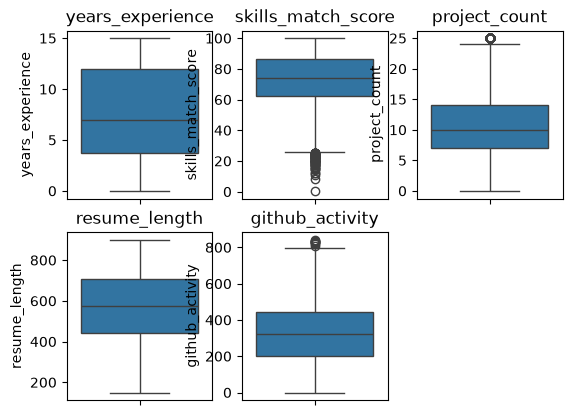

In [29]:
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2,3,i)
    sns.boxplot(y=df[col])
    plt.title(col)

In [30]:
plt.tight_layout()
plt.show()
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: {count} outliers (normal range {lower:.1f} to {upper:.1f})")

<Figure size 640x480 with 0 Axes>

years_experience: 0 outliers (normal range -8.6 to 24.4)
skills_match_score: 81 outliers (normal range 25.5 to 123.1)
project_count: 118 outliers (normal range -3.5 to 24.5)
resume_length: 0 outliers (normal range 39.0 to 1111.0)
github_activity: 9 outliers (normal range -159.5 to 804.5)


In [31]:
def cap_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower, upper)
    return df

In [32]:
for col in numerical_cols:
    df = cap_outliers(df, col)

In [33]:
df.shape

(30000, 7)

In [34]:
df.isnull().sum()

years_experience      0
skills_match_score    0
education_level       0
project_count         0
resume_length         0
github_activity       0
shortlisted           0
dtype: int64

In [35]:
corr_df = df.copy()
corr_df['shortlisted'] = corr_df['shortlisted'].map({'Yes': 1, 'No': 0})
corr_df['education_level'] = corr_df['education_level'].map({'High School': 0, 'Bachelors': 1, 'Masters': 2, 'PhD': 3})

Text(0.5, 1.0, 'Correlation Matrix')

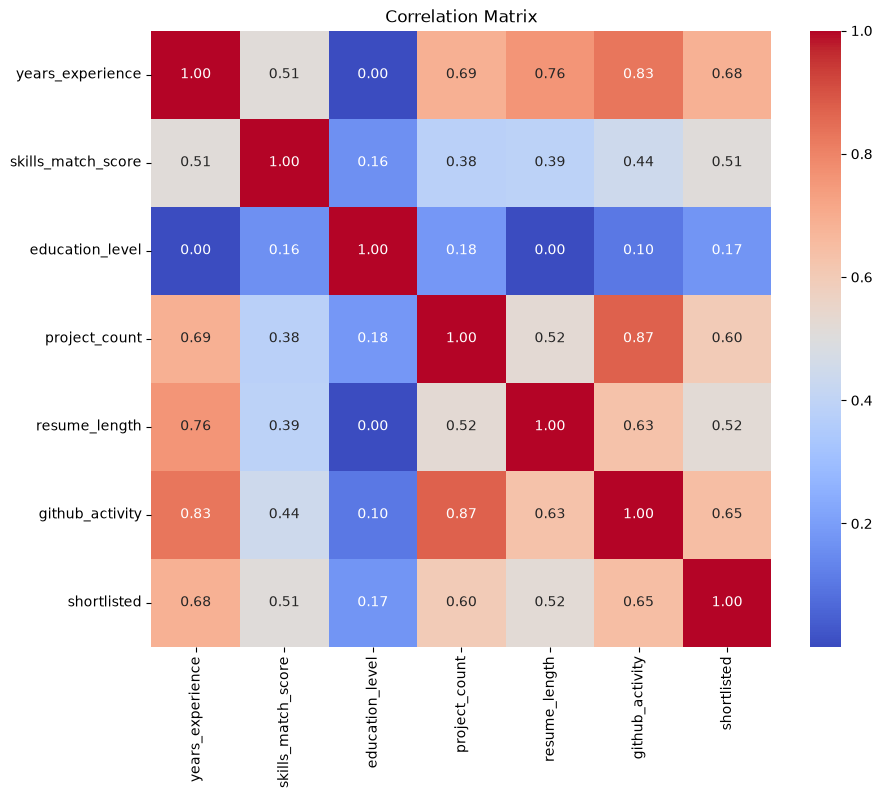

In [36]:
plt.figure(figsize=(10,8))
sns.heatmap(corr_df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')


In [37]:
plt.show()
corr_df.corr(numeric_only=True)['shortlisted'].sort_values(ascending=False)

shortlisted           1.000000
years_experience      0.684845
github_activity       0.646863
project_count         0.600016
resume_length         0.522505
skills_match_score    0.509460
education_level       0.172997
Name: shortlisted, dtype: float64

In [38]:
plt.figure(figsize=(15,8))


<Figure size 1500x800 with 0 Axes>

<Figure size 1500x800 with 0 Axes>

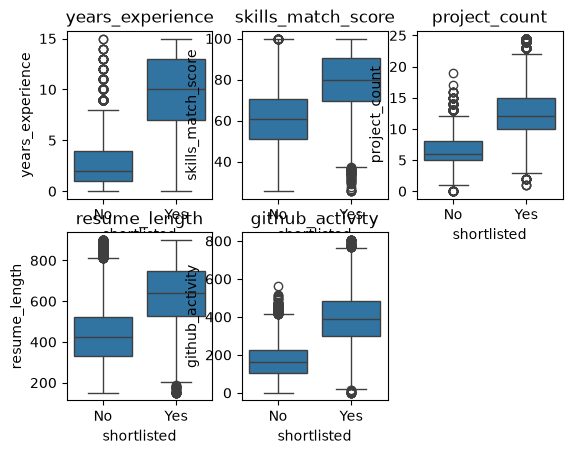

In [39]:
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2,3,i)
    sns.boxplot(x='shortlisted', y=col, data=df)
    plt.title(col)

<Figure size 640x480 with 0 Axes>

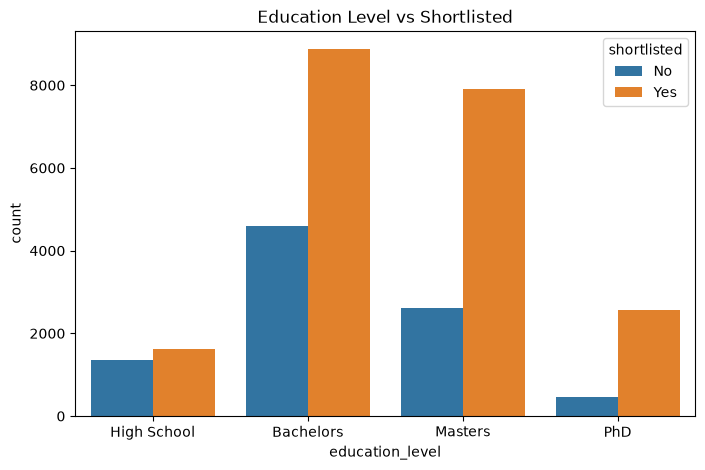

shortlisted,No,Yes
education_level,,
Bachelors,34.128222,65.871778
High School,45.603477,54.396523
Masters,24.857469,75.142531
PhD,15.211640,84.788360


In [40]:
plt.tight_layout()
plt.show()
df.groupby('shortlisted')[list(numerical_cols)].mean()
plt.figure(figsize=(8,5))
sns.countplot(x='education_level', hue='shortlisted', data=df, order=['High School', 'Bachelors', 'Masters', 'PhD'])
plt.title('Education Level vs Shortlisted')
plt.show()
pd.crosstab(df['education_level'], df['shortlisted'], normalize='index') * 100

In [41]:
df['shortlisted'] = df['shortlisted'].map({'Yes': 1, 'No': 0})

In [42]:
edu_mapping = {'High School': 0, 'Bachelors': 1, 'Masters': 2, 'PhD': 3}
df['education_level'] = df['education_level'].map(edu_mapping)


In [43]:
df.head()
df.isnull().sum()


years_experience      0
skills_match_score    0
education_level       0
project_count         0
resume_length         0
github_activity       0
shortlisted           0
dtype: int64

In [44]:

X = df.drop('shortlisted', axis=1)
y = df['shortlisted']
print(X.shape, y.shape)


(30000, 6) (30000,)


In [45]:

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(24000, 6) (6000, 6)
shortlisted
1    0.698875
0    0.301125
Name: proportion, dtype: float64
shortlisted
1    0.698833
0    0.301167
Name: proportion, dtype: float64


In [46]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
pd.DataFrame(X_train_scaled, columns=X.columns).describe().round(2)

,years_experience,skills_match_score,education_level,project_count,resume_length,github_activity
count,24000.00,24000.00,24000.00,24000.00,24000.00,24000.00
mean,-0.00,0.00,-0.00,-0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.62,-2.88,-1.80,-2.30,-2.36,-2.04
25%,-0.98,-0.69,-0.56,-0.79,-0.73,-0.77
50%,0.10,0.04,-0.56,-0.14,0.01,-0.03
75%,0.97,0.76,0.68,0.72,0.76,0.74
max,1.62,1.57,1.92,2.99,1.83,2.99


In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    print(f"{name} trained")

Logistic Regression trained
Decision Tree trained
Random Forest trained
Gradient Boosting trained


In [48]:
predictions = {}
probabilities = {}

for name, model in models.items():
    predictions[name] = model.predict(X_test_scaled)
    probabilities[name] = model.predict_proba(X_test_scaled)[:, 1]

In [49]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

results = []

for name in models:
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, predictions[name]),
        'Precision': precision_score(y_test, predictions[name]),
        'Recall': recall_score(y_test, predictions[name]),
        'F1 Score': f1_score(y_test, predictions[name]),
        'ROC-AUC': roc_auc_score(y_test, probabilities[name])
    })


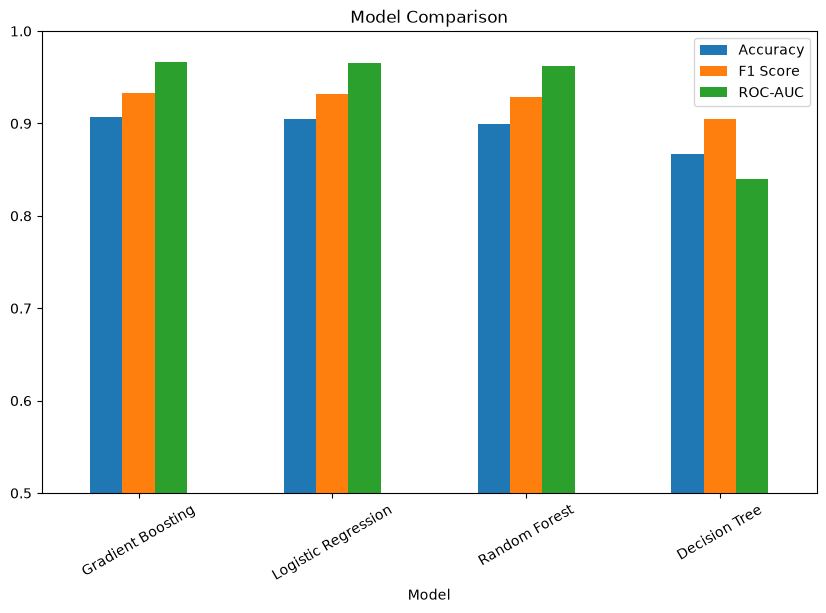

In [50]:
results_df = pd.DataFrame(results).sort_values('F1 Score', ascending=False).round(4)
results_df
results_df.set_index('Model')[['Accuracy', 'F1 Score', 'ROC-AUC']].plot(kind='bar', figsize=(10,6))
plt.ylim(0.5, 1)
plt.title('Model Comparison')
plt.xticks(rotation=30)
plt.show()

Best model: Gradient Boosting


<function matplotlib.pyplot.show(close=None, block=None)>

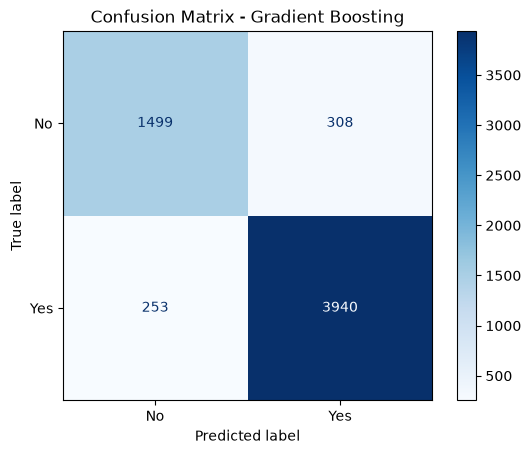

In [51]:
best_name = results_df.iloc[0]['Model']
best_model = models[best_name]
print("Best model:", best_name)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

cm = confusion_matrix(y_test, predictions[best_name])
ConfusionMatrixDisplay(cm, display_labels=['No', 'Yes']).plot(cmap='Blues')
plt.title(f'Confusion Matrix - {best_name}')
plt.show

In [52]:
print(classification_report(y_test, predictions[best_name], target_names=['No', 'Yes']))

              precision    recall  f1-score   support

          No       0.86      0.83      0.84      1807
         Yes       0.93      0.94      0.93      4193

    accuracy                           0.91      6000
   macro avg       0.89      0.88      0.89      6000
weighted avg       0.91      0.91      0.91      6000



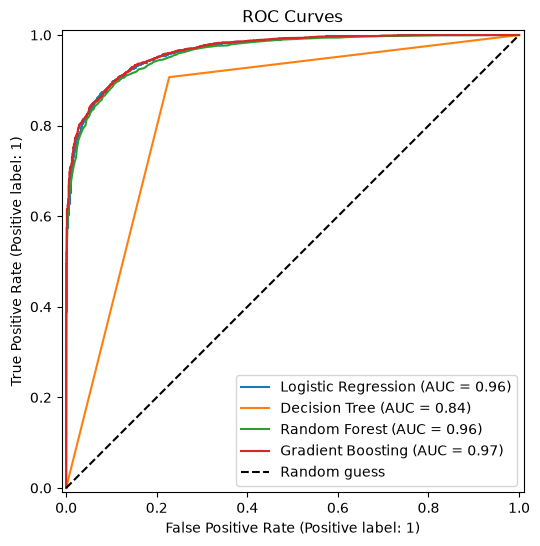

In [53]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8,6))

for name in models:
    RocCurveDisplay.from_predictions(y_test, probabilities[name], name=name, ax=ax)

ax.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.title('ROC Curves')
plt.legend()
plt.show()

In [54]:
for name, model in models.items():
    train_acc = model.score(X_train_scaled, y_train)
    test_acc = model.score(X_test_scaled, y_test)
    print(f"{name:20s} train: {train_acc:.4f}  test: {test_acc:.4f}  gap: {train_acc - test_acc:.4f}")
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Logistic Regression  train: 0.9081  test: 0.9043  gap: 0.0038
Decision Tree        train: 1.0000  test: 0.8665  gap: 0.1335
Random Forest        train: 1.0000  test: 0.8995  gap: 0.1005
Gradient Boosting    train: 0.9157  test: 0.9065  gap: 0.0092


In [ ]:
for name in results_df['Model'].head(3):
    scores = cross_val_score(models[name], X_train_scaled, y_train, cv=cv, scoring='f1')
    print(f"{name:20s} F1: {scores.mean():.4f} ± {scores.std():.4f}")

In [ ]:
if hasattr(best_model, 'feature_importances_'):
    importance = best_model.feature_importances_
else:
    importance = np.abs(best_model.coef_[0])

feat_imp = pd.Series(importance, index=X.columns).sort_values()

feat_imp.plot(kind='barh', figsize=(8,5))
plt.title(f'Feature Importance - {best_name}')
plt.show()

In [ ]:
comparison = pd.DataFrame({
    'Actual': y_test.map({1: 'Yes', 0: 'No'}).values,
    'Predicted': pd.Series(predictions[best_name]).map({1: 'Yes', 0: 'No'}).values,
    'Probability (Yes)': probabilities[best_name].round(3)
})
comparison.head(10)

In [59]:
def screen_candidates(candidates, threshold=0.5):
    data = candidates.copy()
    data['education_level'] = data['education_level'].map(edu_mapping)
    data_scaled = scaler.transform(data[X.columns])

    result = candidates.copy()
    result['probability'] = best_model.predict_proba(data_scaled)[:, 1].round(3)
    result['decision'] = np.where(result['probability'] >= threshold, 'Shortlist', 'Reject')
    return result.sort_values('probability', ascending=False)


In [60]:
new_candidates = pd.DataFrame({
    'years_experience': [8, 1],
    'skills_match_score': [91.5, 48.0],
    'education_level': ['Masters', 'High School'],
    'project_count': [14, 3],
    'resume_length': [720, 260],
    'github_activity': [480, 60]
}, index=['Candidate A', 'Candidate B'])

screen_candidates(new_candidates)


,years_experience,skills_match_score,education_level,project_count,resume_length,github_activity,probability,decision
Candidate A,8,91.5,Masters,14,720,480,0.993,Shortlist
Candidate B,1,48.0,High School,3,260,60,0.009,Reject


In [61]:
raw_df = pd.read_csv("ai_resume_screening.csv")

applicant_pool = raw_df.loc[X_test.index].sample(50, random_state=42)
actual_labels = applicant_pool.pop('shortlisted')

ranked = screen_candidates(applicant_pool)
ranked['actual'] = actual_labels
ranked.head(10)
top_n = 10
hits = (ranked.head(top_n)['actual'] == 'Yes').sum()
print(f"{hits} of the top {top_n} ranked candidates were actually shortlisted in the real data")
strong = ranked[ranked['probability'] >= 0.8]
print(f"{len(strong)} of {len(ranked)} applicants have 80%+ probability")
strong

10 of the top 10 ranked candidates were actually shortlisted in the real data
33 of 50 applicants have 80%+ probability


,years_experience,skills_match_score,education_level,project_count,resume_length,github_activity,probability,decision,actual
22473,15,94.1,PhD,17,741,511,0.997,Shortlist,Yes
20146,13,86.1,Masters,17,715,546,0.997,Shortlist,Yes
9711,12,100.0,Bachelors,18,619,431,0.996,Shortlist,Yes
7068,13,62.0,PhD,16,645,566,0.995,Shortlist,Yes
17969,11,75.8,Masters,15,792,437,0.995,Shortlist,Yes
3696,13,100.0,Masters,14,884,499,0.995,Shortlist,Yes
5941,9,87.3,Masters,20,590,603,0.994,Shortlist,Yes
18583,14,92.8,High School,19,308,654,0.994,Shortlist,Yes
3740,10,73.3,Bachelors,21,621,581,0.993,Shortlist,Yes
11323,12,73.8,Bachelors,11,744,429,0.992,Shortlist,Yes


In [62]:
for t in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    preds = (probabilities[best_name] >= t).astype(int)
    print(f"threshold {t:.1f} | precision {precision_score(y_test, preds):.4f} | "
          f"recall {recall_score(y_test, preds):.4f} | F1 {f1_score(y_test, preds):.4f} | "
          f"shortlisted {preds.sum()}")


threshold 0.3 | precision 0.8960 | recall 0.9676 | F1 0.9304 | shortlisted 4528
threshold 0.4 | precision 0.9136 | recall 0.9537 | F1 0.9333 | shortlisted 4377
threshold 0.5 | precision 0.9275 | recall 0.9397 | F1 0.9335 | shortlisted 4248
threshold 0.6 | precision 0.9404 | recall 0.9177 | F1 0.9289 | shortlisted 4092
threshold 0.7 | precision 0.9526 | recall 0.8963 | F1 0.9236 | shortlisted 3945
threshold 0.8 | precision 0.9654 | recall 0.8583 | F1 0.9087 | shortlisted 3728
threshold 0.9 | precision 0.9850 | recall 0.7975 | F1 0.8814 | shortlisted 3395


In [63]:
import joblib
import os

os.makedirs('models', exist_ok=True)

joblib.dump(best_model, 'models/resume_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump({'edu_mapping': edu_mapping,
             'feature_order': list(X.columns),
             'model_name': best_name}, 'models/metadata.pkl')

print("Saved:", os.listdir('models'))

Saved: ['.ipynb_checkpoints', 'metadata.pkl', 'resume_model.pkl', 'scaler.pkl']


In [64]:
loaded_model = joblib.load('models/resume_model.pkl')
loaded_scaler = joblib.load('models/scaler.pkl')
metadata = joblib.load('models/metadata.pkl')

test_candidate = pd.DataFrame({
    'years_experience': [8],
    'skills_match_score': [90.0],
    'education_level': ['Bachelors'],
    'project_count': [12],
    'resume_length': [650],
    'github_activity': [420]
})

test_candidate['education_level'] = test_candidate['education_level'].map(metadata['edu_mapping'])
test_candidate = test_candidate[metadata['feature_order']]

prob = loaded_model.predict_proba(loaded_scaler.transform(test_candidate))[0, 1]
print(f"{metadata['model_name']} -> Shortlisted: {'Yes' if prob >= 0.5 else 'No'} ({prob*100:.1f}% probability)")


Gradient Boosting -> Shortlisted: Yes (98.7% probability)


In [65]:
%%writefile app.py
import joblib
import pandas as pd
import streamlit as st

model = joblib.load('models/resume_model.pkl')
scaler = joblib.load('models/scaler.pkl')
metadata = joblib.load('models/metadata.pkl')

st.title('AI Resume Screening')
st.caption(f"Model: {metadata['model_name']}")

years_experience = st.number_input('Years of experience', 0, 40, 5)
skills_match_score = st.slider('Skills match score', 0.0, 100.0, 75.0)
education_level = st.selectbox('Education level', list(metadata['edu_mapping'].keys()))
project_count = st.number_input('Project count', 0, 50, 10)
resume_length = st.number_input('Resume length', 50, 2000, 550)
github_activity = st.number_input('GitHub activity', 0, 2000, 300)

if st.button('Screen candidate'):
    candidate = pd.DataFrame({
        'years_experience': [years_experience],
        'skills_match_score': [skills_match_score],
        'education_level': [metadata['edu_mapping'][education_level]],
        'project_count': [project_count],
        'resume_length': [resume_length],
        'github_activity': [github_activity]
    })[metadata['feature_order']]

    prob = model.predict_proba(scaler.transform(candidate))[0, 1]

    if prob >= 0.5:
        st.success(f"Shortlisted ({prob*100:.1f}% probability)")
    else:
        st.error(f"Not shortlisted ({prob*100:.1f}% probability)")


Overwriting app.py


## Conclusion

*Dataset:* 30,000 candidates, 6 features, target shortlisted (70% Yes / 30% No).

*Cleaning:* no missing values, no duplicates, no invalid values. Outliers were capped, not removed
(81 in skills_match_score, 118 in project_count, 9 in github_activity).

*Best model:* __ with Accuracy _, F1 _, ROC-AUC _
(baseline "always Yes": Accuracy 0.70, F1 0.82, ROC-AUC 0.50).

*Most important features:* __, __, __.

*Shortlisting:* candidates are ranked by predicted probability and the top N (or everyone above a
threshold of _) is shortlisted. _ of the top 10 in the test batch were truly shortlisted.

*Limitations:*
- The dataset is synthetic; real hiring data is messier.
- Only 6 numeric features are used; the model does not read the actual resume text.
- Features like education can carry bias, so a human should review final decisions.## Conclusion

*Dataset:* 30,000 candidates, 6 features, target shortlisted (70% Yes / 30% No).

*Cleaning:* no missing values, no duplicates, no invalid values. Outliers were capped, not removed
(81 in skills_match_score, 118 in project_count, 9 in github_activity).

*Best model:* __ with Accuracy _, F1 _, ROC-AUC _
(baseline "always Yes": Accuracy 0.70, F1 0.82, ROC-AUC 0.50).

*Most important features:* __, __, __.

*Shortlisting:* candidates are ranked by predicted probability and the top N (or everyone above a
threshold of _) is shortlisted. _ of the top 10 in the test batch were truly shortlisted.

*Limitations:*
- The dataset is synthetic; real hiring data is messier.
- Only 6 numeric features are used; the model does not read the actual resume text.
- Features like education can carry bias, so a human should review final decisions.

In [67]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier

# 1. Fit scaler on training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# 2. Train Gradient Boosting Classifier
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train_scaled, y_train)

print("Scaler and Gradient Boosting model successfully trained and assigned to 'scaler' and 'gb'!")

Scaler and Gradient Boosting model successfully trained and assigned to 'scaler' and 'gb'!


In [68]:
import os
import joblib

# 1. Create the models directory
os.makedirs('models', exist_ok=True)

# 2. Save the best model (Gradient Boosting)
joblib.dump(gb, 'models/resume_model.pkl')

# 3. Save the fitted scaler
joblib.dump(scaler, 'models/scaler.pkl')

# 4. Save metadata matching your app logic
metadata = {
    'model_name': 'Gradient Boosting',
    'edu_mapping': {
        'High School': 0,
        'Bachelors': 1,
        'Masters': 2,
        'PhD': 3
    },
    'feature_order': X_train.columns.tolist()
}

joblib.dump(metadata, 'models/metadata.pkl')

print("Model, scaler, and metadata saved successfully in 'models/' folder!")

Model, scaler, and metadata saved successfully in 'models/' folder!
